In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [7]:
df = pd.read_csv("Housing.csv")   # 🔴 CHANGE FILE

# Handle missing values
df = df.fillna(df.mean(numeric_only=True))
df = df.bfill()

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Split
target = "price"   # 🔴 CHANGE TARGET

X = df[['area', 'bedrooms', 'bathrooms']]
y = df[target]

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression


model1 = LinearRegression()


# Train
model1.fit(X_train, y_train)


# Predict
y_pred1 = model1.predict(X_test)


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_test, y_pred):
    print(f"\n🔹 {name} Results")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
# Evaluate both models
evaluate_model("Linear Regression", y_test, y_pred1)



🔹 Linear Regression Results
MAE : 1265275.669945438
MSE : 2750040479309.0522
RMSE: 1658324.6001036866
R2 Score: 0.4559299118872445


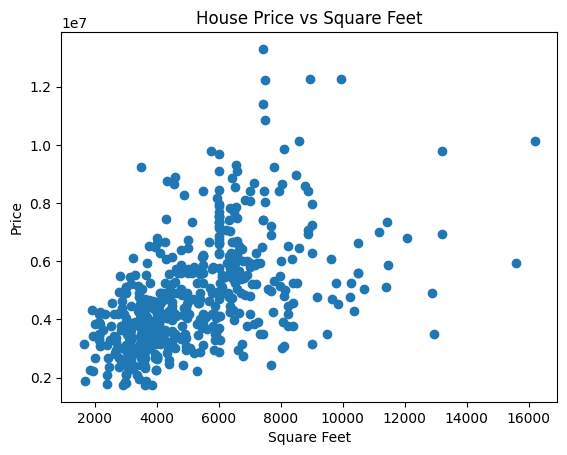

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df['area'], df['price'])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("House Price vs Square Feet")
plt.show()